# ECON 5140: Applied Econometrics
## Lesson 9: Matching for Causal Inference

This notebook demonstrates how **different matching methods** are used to estimate the **Average Treatment Effect (ATE)** for causal inference.

**Goal:** Compare ATE estimates from:
1. Naive comparison (biased)
2. Exact matching
3. Nearest-neighbor matching (covariate distance)
4. Propensity score matching
5. Inverse probability weighting (IPW)

We use simulated data with a known true ATE to assess bias reduction.

## Setup

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from scipy.spatial.distance import cdist
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## Shared Data: Job Training and Earnings

We simulate a dataset where:
- **D = 1**: Received job training; **D = 0**: Did not
- **Y**: Earnings (outcome)
- **X1, X2, education**: Pre-treatment covariates that affect both treatment and outcome

**True DGP:** Y = 50 + **10**×D + 5×X1 + 5×X2 + 3×education + noise → **True ATE = 10**

Because X affects both D and Y, the naive comparison is biased. Matching methods aim to recover the true ATE.

In [95]:
# Generate shared dataset for all matching methods
np.random.seed(42)
n = 500
X1 = np.random.normal(0, 1, n)
X2 = np.clip(np.random.normal(0, 1, n), -2, 2)
education = np.random.choice([0, 1, 2], n, p=[0.4, 0.35, 0.25])  # For exact matching

# Treatment: selection on observables (X and education affect D)
logit_p = -0.5 + 0.4*X1 + 0.4*X2 + 0.3*education
ps_true = 1 / (1 + np.exp(-logit_p))
D = (np.random.uniform(0, 1, n) < ps_true).astype(int)

# Outcome: Y = 50 + 10*D + 5*X1 + 5*X2 + 3*education + noise  (True ATE = 10)
Y = 50 + 10*D + 5*X1 + 5*X2 + 3*education + np.random.normal(0, 5, n)

df = pd.DataFrame({'X1': X1, 'X2': X2, 'education': education, 'D': D, 'Y': Y})
TRUE_ATE = 10.0

print("Dataset summary:")
print(f"  n = {len(df)}, Treated: {D.sum()}, Control: {n - D.sum()}")
print(f"  True ATE = {TRUE_ATE}")

Dataset summary:
  n = 500, Treated: 215, Control: 285
  True ATE = 10.0


In [96]:
df.head()

,X1,X2,education,D,Y
0,0.496714,0.926178,0,0,55.568413
1,-0.138264,1.909417,0,1,65.094980
2,0.647689,-1.398568,1,1,60.841477
3,1.523030,0.562969,1,1,80.132248
4,-0.234153,-0.650643,0,0,36.200158


## Covariate Imbalance (Before Treatment)

Because treatment is not random—covariates affect both D and Y—the **treated** and **control** groups have different covariate distributions. The plots below show that X1, X2, and education are **not balanced** between groups. This motivates matching and IPW: we need to balance covariates to estimate causal effects.

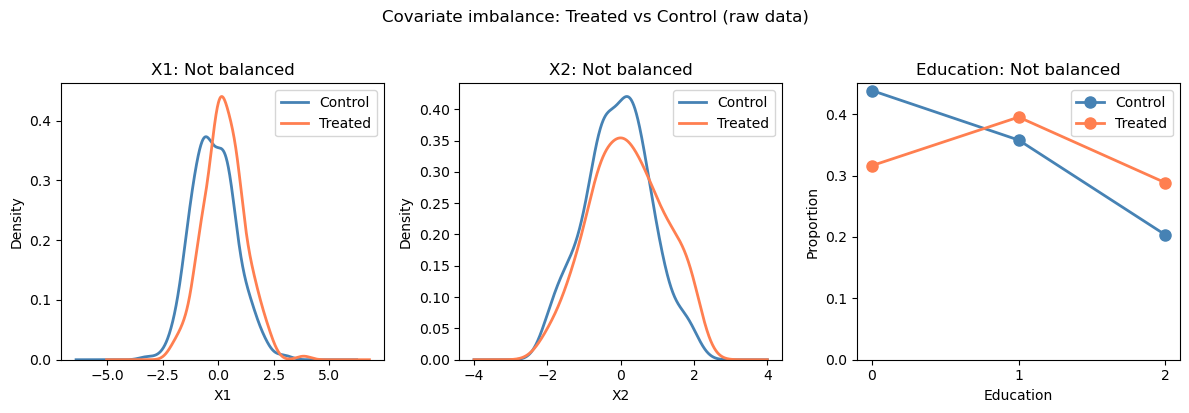

In [107]:
# Imbalance: distributions of X1, X2, education by treatment (KDE / line)
treated = df[df['D']==1]
control = df[df['D']==0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# X1 (KDE)
control['X1'].plot(kind='kde', ax=axes[0], label='Control', color='steelblue', linewidth=2)
treated['X1'].plot(kind='kde', ax=axes[0], label='Treated', color='coral', linewidth=2)
axes[0].set_xlabel('X1')
axes[0].set_ylabel('Density')
axes[0].set_title('X1: Not balanced')
axes[0].legend()
axes[0].set_ylim(bottom=0)

# X2 (KDE)
control['X2'].plot(kind='kde', ax=axes[1], label='Control', color='steelblue', linewidth=2)
treated['X2'].plot(kind='kde', ax=axes[1], label='Treated', color='coral', linewidth=2)
axes[1].set_xlabel('X2')
axes[1].set_ylabel('Density')
axes[1].set_title('X2: Not balanced')
axes[1].legend()
axes[1].set_ylim(bottom=0)

# Education (line plot)
edu_vals = sorted(df['education'].unique())
ctrl_pct = [control['education'].value_counts(normalize=True).get(e, 0) for e in edu_vals]
trt_pct = [treated['education'].value_counts(normalize=True).get(e, 0) for e in edu_vals]
x = np.arange(len(edu_vals))
axes[2].plot(x, ctrl_pct, 'o-', label='Control', color='steelblue', linewidth=2, markersize=8)
axes[2].plot(x, trt_pct, 'o-', label='Treated', color='coral', linewidth=2, markersize=8)
axes[2].set_xlabel('Education')
axes[2].set_ylabel('Proportion')
axes[2].set_title('Education: Not balanced')
axes[2].set_xticks(x)
axes[2].set_xticklabels(edu_vals)
axes[2].legend()
axes[2].set_ylim(bottom=0)

plt.suptitle('Covariate imbalance: Treated vs Control (raw data)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Method 1: Naive Comparison (Baseline)

The **naive ATE** is the simple difference in means: E[Y|D=1] − E[Y|D=0]. This is biased when treatment is not random—i.e., when covariates affect both D and Y.

In [98]:
# Naive ATE: simple difference in means
ate_naive = df[df['D']==1]['Y'].mean() - df[df['D']==0]['Y'].mean()
t_naive, pval_naive = stats.ttest_ind(df[df['D']==1]['Y'], df[df['D']==0]['Y'])
se_naive = abs(ate_naive / t_naive) if t_naive != 0 else np.nan

print("Method 1: Naive comparison")
print(f"  ATE_naive = E[Y|D=1] - E[Y|D=0] = {ate_naive:.2f} (SE = {se_naive:.2f}, p = {pval_naive:.4f})")
print(f"  True ATE = {TRUE_ATE}")
print(f"  Bias = {ate_naive - TRUE_ATE:.2f}")

Method 1: Naive comparison
  ATE_naive = E[Y|D=1] - E[Y|D=0] = 14.25 (SE = 0.75, p = 0.0000)
  True ATE = 10.0
  Bias = 4.25


## Method 2: Exact Matching

**Exact matching** pairs units with **identical** covariate values. For ATE:
- Treated: impute Y(0) = mean outcome of controls in same stratum
- Control: impute Y(1) = mean outcome of treated in same stratum
- ATE = mean(Y1_hat − Y0_hat) over all units

In [99]:
# Step 1: For each education stratum, compute mean Y among treated and among control
print("Step 1: Within each education stratum, compute mean Y for treated vs control")
print("-" * 55)
for edu in sorted(df['education'].unique()):
    stratum = df[df['education'] == edu]
    treated_in_stratum = stratum[stratum['D'] == 1]
    control_in_stratum = stratum[stratum['D'] == 0]
    if len(treated_in_stratum) > 0 and len(control_in_stratum) > 0:
        mean_Y1 = treated_in_stratum['Y'].mean()  # E[Y(1)|education=edu]
        mean_Y0 = control_in_stratum['Y'].mean()  # E[Y(0)|education=edu]
        print(f"  Education={edu}: mean Y treated={mean_Y1:.2f}, mean Y control={mean_Y0:.2f}")
print()

# Step 2: For each unit, impute the missing counterfactual from same stratum
print("Step 2: Impute counterfactual for each unit from same-education stratum")
print("  - If D=1 (treated): we observe Y(1), impute Y(0) = mean Y of controls in stratum")
print("  - If D=0 (control): we observe Y(0), impute Y(1) = mean Y of treated in stratum")
print()

Y1_hat = np.zeros(len(df))
Y0_hat = np.zeros(len(df))
for edu in df['education'].unique():
    mask = df['education'] == edu
    treated_in_stratum = df[mask & (df['D']==1)]
    control_in_stratum = df[mask & (df['D']==0)]
    mean_Y1 = treated_in_stratum['Y'].mean()
    mean_Y0 = control_in_stratum['Y'].mean()
    # Treated: Y1_hat = observed Y; Y0_hat = mean of controls
    # Control: Y0_hat = observed Y; Y1_hat = mean of treated
    Y1_hat[mask] = np.where(df.loc[mask, 'D']==1, df.loc[mask, 'Y'], mean_Y1)
    Y0_hat[mask] = np.where(df.loc[mask, 'D']==0, df.loc[mask, 'Y'], mean_Y0)

# Step 3: ATE = mean of (Y1_hat - Y0_hat) over all units
ite_exact = Y1_hat - Y0_hat
ate_exact = np.nanmean(ite_exact)
se_exact = np.nanstd(ite_exact) / np.sqrt(np.sum(~np.isnan(ite_exact)))
pval_exact = 2 * (1 - stats.t.cdf(abs(ate_exact / se_exact), len(ite_exact) - 1)) if se_exact > 0 else 0
att_exact = np.nanmean(ite_exact[df['D'].values==1])
ite_treated = ite_exact[df['D'].values==1]
se_att_exact = np.nanstd(ite_treated) / np.sqrt(len(ite_treated)) if len(ite_treated) > 0 else 0
pval_att_exact = 2 * (1 - stats.t.cdf(abs(att_exact / se_att_exact), len(ite_treated) - 1)) if se_att_exact > 0 else 0
print("Step 3: ATE = mean(Y1_hat - Y0_hat) over all units")
print(f"  ATE_exact = {ate_exact:.2f} (SE = {se_exact:.2f}, p = {pval_exact:.4f})")
print(f"  ATT_exact = {att_exact:.2f} (SE = {se_att_exact:.2f}, p = {pval_att_exact:.4f})")
print(f"  True ATE = {TRUE_ATE}")
print(f"  Bias = {ate_exact - TRUE_ATE:.2f}")

Step 1: Within each education stratum, compute mean Y for treated vs control
-------------------------------------------------------
  Education=0: mean Y treated=60.78, mean Y control=48.53
  Education=1: mean Y treated=65.76, mean Y control=52.24
  Education=2: mean Y treated=68.64, mean Y control=53.01

Step 2: Impute counterfactual for each unit from same-education stratum
  - If D=1 (treated): we observe Y(1), impute Y(0) = mean Y of controls in stratum
  - If D=0 (control): we observe Y(0), impute Y(1) = mean Y of treated in stratum

Step 3: ATE = mean(Y1_hat - Y0_hat) over all units
  ATE_exact = 13.54 (SE = 0.36, p = 0.0000)
  ATT_exact = 13.73 (SE = 0.54, p = 0.0000)
  True ATE = 10.0
  Bias = 3.54


## Method 3: Nearest-Neighbor Matching (Covariate Distance)

**Nearest-neighbor matching:** For each unit, find the closest unit in the other group (by Euclidean distance in covariate space) and use their outcome as the imputed counterfactual.

For ATE: Treated get Y(0) from nearest control; controls get Y(1) from nearest treated.

In [100]:
# Nearest-neighbor matching on (X1, X2) — with replacement
X_covars = df[['X1', 'X2']].values
X_treated = df[df['D']==1][['X1','X2']].values
X_control = df[df['D']==0][['X1','X2']].values
Y_treated = df[df['D']==1]['Y'].values
Y_control = df[df['D']==0]['Y'].values

# Treated → nearest control (impute Y0)
## cdist outputs distance from each treated unit to each control unit
dist_t2c = cdist(X_treated, X_control, metric='euclidean')
nearest_c = np.argmin(dist_t2c, axis=1)
Y0_hat_treated = Y_control[nearest_c]

# Control → nearest treated (impute Y1)
dist_c2t = cdist(X_control, X_treated, metric='euclidean')
nearest_t = np.argmin(dist_c2t, axis=1)
Y1_hat_control = Y_treated[nearest_t]

# ATE = (1/n)[sum_treated(Y - Y0_hat) + sum_control(Y1_hat - Y)]
ate_nn = (np.sum(Y_treated - Y0_hat_treated) + np.sum(Y1_hat_control - Y_control)) / len(df)

att_nn = (Y_treated - Y0_hat_treated).mean()

# Bootstrap SE (matched obs not independent; naive SE wrong)
ate_boot, att_boot = [], []
for _ in range(200):
    idx = np.random.choice(len(df), len(df), replace=True)
    b = df.iloc[idx]
    Xt = b[b['D']==1][['X1','X2']].values
    Xc = b[b['D']==0][['X1','X2']].values
    Yt = b[b['D']==1]['Y'].values
    Yc = b[b['D']==0]['Y'].values
    if len(Xt)>0 and len(Xc)>0:
        d_t2c = cdist(Xt, Xc, metric='euclidean')
        d_c2t = cdist(Xc, Xt, metric='euclidean')
        y0_t = Yc[np.argmin(d_t2c, axis=1)]
        y1_c = Yt[np.argmin(d_c2t, axis=1)]
        ate_boot.append((np.sum(Yt - y0_t) + np.sum(y1_c - Yc)) / len(b))
        att_boot.append((Yt - y0_t).mean())
se_nn = np.std(ate_boot)
se_att_nn = np.std(att_boot)
pval_nn = 2 * (1 - stats.norm.cdf(abs(ate_nn / se_nn))) if se_nn > 0 else 0
pval_att_nn = 2 * (1 - stats.norm.cdf(abs(att_nn / se_att_nn))) if se_att_nn > 0 else 0

print("Method 3: Nearest-neighbor matching (Euclidean, with replacement)")
print(f"  ATE_nn = {ate_nn:.2f} (SE = {se_nn:.2f}, p = {pval_nn:.4f})")
print(f"  ATT_nn = {att_nn:.2f} (SE = {se_att_nn:.2f}, p = {pval_att_nn:.4f})")
print(f"  True ATE = {TRUE_ATE}")
print(f"  Bias = {ate_nn - TRUE_ATE:.2f}")

Method 3: Nearest-neighbor matching (Euclidean, with replacement)
  ATE_nn = 10.97 (SE = 0.53, p = 0.0000)
  ATT_nn = 11.62 (SE = 0.70, p = 0.0000)
  True ATE = 10.0
  Bias = 0.97


## Method 4: Propensity Score Matching

**Propensity score:** $e(X) = \Pr(D=1|X)$. Match on $e(X)$ instead of full $X$ (Rosenbaum–Rubin).

For ATE: Same as nearest-neighbor, but distance is on propensity score. Treated get Y(0) from nearest control (by PS); controls get Y(1) from nearest treated.

In [101]:
# Propensity score matching on shared df
logit = LogisticRegression(C=1e10, max_iter=1000)
logit.fit(df[['X1','X2','education']], df['D'])
df['ps'] = logit.predict_proba(df[['X1','X2','education']])[:, 1]

ps_treated = df[df['D']==1]['ps'].values.reshape(-1, 1)
ps_control = df[df['D']==0]['ps'].values.reshape(-1, 1)
Y_treated = df[df['D']==1]['Y'].values
Y_control = df[df['D']==0]['Y'].values

# Treated -> nearest control (impute Y0)
dist_ps_t2c = cdist(ps_treated, ps_control, metric='euclidean')
nearest_c_ps = np.argmin(dist_ps_t2c, axis=1)
Y0_hat_ps_treated = Y_control[nearest_c_ps]

# Control -> nearest treated (impute Y1)
dist_ps_c2t = cdist(ps_control, ps_treated, metric='euclidean')
nearest_t_ps = np.argmin(dist_ps_c2t, axis=1)
Y1_hat_ps_control = Y_treated[nearest_t_ps]

ate_ps = (np.sum(Y_treated - Y0_hat_ps_treated) + np.sum(Y1_hat_ps_control - Y_control)) / len(df)
att_ps = (Y_treated - Y0_hat_ps_treated).mean()

# Bootstrap SE (matched obs not independent)
ate_boot_ps, att_boot_ps = [], []
for _ in range(200):
    idx = np.random.choice(len(df), len(df), replace=True)
    b = df.iloc[idx]
    logit_b = LogisticRegression(C=1e10, max_iter=1000)
    logit_b.fit(b[['X1','X2','education']], b['D'])
    pt_ps = logit_b.predict_proba(b[b['D']==1][['X1','X2','education']])[:, 1].reshape(-1, 1)
    pc_ps = logit_b.predict_proba(b[b['D']==0][['X1','X2','education']])[:, 1].reshape(-1, 1)
    Ytb = b[b['D']==1]['Y'].values
    Ycb = b[b['D']==0]['Y'].values
    if len(pt_ps)>0 and len(pc_ps)>0:
        d_t2c = cdist(pt_ps, pc_ps, metric='euclidean')
        d_c2t = cdist(pc_ps, pt_ps, metric='euclidean')
        y0_t = Ycb[np.argmin(d_t2c, axis=1)]
        y1_c = Ytb[np.argmin(d_c2t, axis=1)]
        ate_boot_ps.append((np.sum(Ytb - y0_t) + np.sum(y1_c - Ycb)) / len(b))
        att_boot_ps.append((Ytb - y0_t).mean())
se_ps = np.std(ate_boot_ps)
se_att_ps = np.std(att_boot_ps)
pval_ps = 2 * (1 - stats.norm.cdf(abs(ate_ps / se_ps))) if se_ps > 0 else 0
pval_att_ps = 2 * (1 - stats.norm.cdf(abs(att_ps / se_att_ps))) if se_att_ps > 0 else 0

print("Method 4: Propensity score matching")
print(f"  ATE_ps = {ate_ps:.2f} (SE = {se_ps:.2f}, p = {pval_ps:.4f})")
print(f"  ATT_ps = {att_ps:.2f} (SE = {se_att_ps:.2f}, p = {pval_att_ps:.4f})")
print(f"  True ATE = {TRUE_ATE}")
print(f"  Bias = {ate_ps - TRUE_ATE:.2f}")

Method 4: Propensity score matching
  ATE_ps = 9.94 (SE = 0.56, p = 0.0000)
  ATT_ps = 10.10 (SE = 0.70, p = 0.0000)
  True ATE = 10.0
  Bias = -0.06


### Overlap Check

**Overlap** requires $0 < \Pr(D=1|X) < 1$: every unit has comparable units in the other group. Without overlap, matching and IPW fail (we extrapolate counterfactuals).

Check: Do the propensity score distributions of treated and control overlap?

Propensity score ranges:
  Treated: min = 0.152, max = 0.887
  Control: min = 0.105, max = 0.840

  Common support: [0.152, 0.840]
  Units outside common support: 8 (of 500)



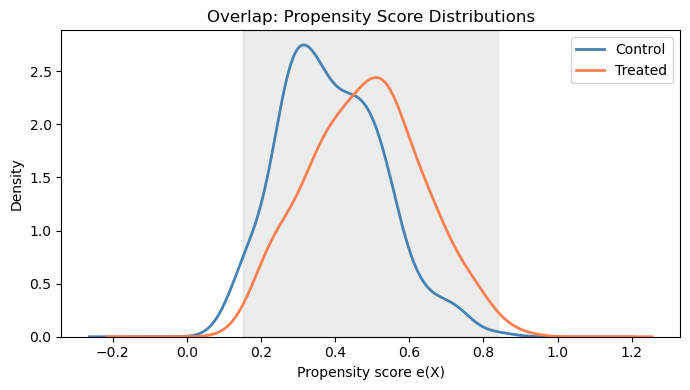

In [102]:
# Overlap: compare propensity score ranges
ps_treated_vals = df[df['D']==1]['ps']
ps_control_vals = df[df['D']==0]['ps']

print("Propensity score ranges:")
print(f"  Treated: min = {ps_treated_vals.min():.3f}, max = {ps_treated_vals.max():.3f}")
print(f"  Control: min = {ps_control_vals.min():.3f}, max = {ps_control_vals.max():.3f}")
print()

# Common support: overlap region
overlap_min = max(ps_treated_vals.min(), ps_control_vals.min())
overlap_max = min(ps_treated_vals.max(), ps_control_vals.max())
print(f"  Common support: [{overlap_min:.3f}, {overlap_max:.3f}]")
n_outside = ((ps_treated_vals < overlap_min) | (ps_treated_vals > overlap_max)).sum() + \
            ((ps_control_vals < overlap_min) | (ps_control_vals > overlap_max)).sum()
print(f"  Units outside common support: {n_outside} (of {len(df)})")
print()

# Plot overlap
fig, ax = plt.subplots(figsize=(7, 4))
ps_control_vals.plot(kind='kde', ax=ax, label='Control', color='steelblue', linewidth=2)
ps_treated_vals.plot(kind='kde', ax=ax, label='Treated', color='coral', linewidth=2)
ax.set_xlabel('Propensity score e(X)')
ax.set_ylabel('Density')
ax.set_title('Overlap: Propensity Score Distributions')
ax.legend()
ax.axvspan(overlap_min, overlap_max, alpha=0.15, color='gray')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## Balance Check (Optional Diagnostic)

After propensity score matching, we assess **balance** on covariates. |SMD| < 0.1 = good.

In [ ]:
def smd(x_treated, x_control):
    """Standardized mean difference."""
    m1, m0 = x_treated.mean(), x_control.mean()
    s1, s0 = x_treated.std(), x_control.std()
    pooled_std = np.sqrt((s1**2 + s0**2) / 2)
    if pooled_std < 1e-10:
        return 0
    return (m1 - m0) / pooled_std

treated = df[df['D']==1]
control = df[df['D']==0]

print("Balance BEFORE matching:")
for col in ['X1', 'X2', 'ps']:
    s = smd(treated[col], control[col])
    status = 'OK' if abs(s) < 0.1 else ('~' if abs(s) < 0.2 else 'poor')
    print(f"  {col}: SMD = {s:+.3f} {status}")
print()

control_idx = df[df['D']==0].index[nearest_c_ps]
matched_control = df.loc[control_idx]

print("Balance AFTER propensity score matching:")
for col in ['X1', 'X2', 'ps']:
    s = smd(treated[col], matched_control[col])
    status = 'OK' if abs(s) < 0.1 else ('~' if abs(s) < 0.2 else 'poor')
    print(f"  {col}: SMD = {s:+.3f} {status}")

Balance BEFORE matching:
  X1: SMD = +0.473 poor
  X2: SMD = +0.277 poor
  ps: SMD = +0.643 poor

Balance AFTER propensity score matching:
  X1: SMD = -0.112 ~
  X2: SMD = +0.125 ~
  ps: SMD = +0.003 OK


## Method 5: Inverse Probability Weighting (IPW)

**IPW** reweights all observations instead of matching.

- **ATE:** weights $1/e(X)$ for treated, $1/(1-e(X))$ for controls.
- **ATT:** treated get weight 1; controls get weight $e(X)/(1-e(X))$ to resemble the treated population.

In [104]:
# IPW for ATE and ATT (use df with ps from Method 4)
ps_clip = np.clip(df['ps'], 0.01, 0.99)

# ATE: weights 1/e for treated, 1/(1-e) for controls
ate_ipw = (df['D'] * df['Y'] / ps_clip).sum() / (df['D'] / ps_clip).sum() - \
          ((1-df['D']) * df['Y'] / (1-ps_clip)).sum() / ((1-df['D']) / (1-ps_clip)).sum()

# ATT: treated weight=1; controls weight e/(1-e)
att_ipw = (df['D'] * df['Y']).sum() / df['D'].sum() - \
          ((1-df['D']) * (ps_clip/(1-ps_clip)) * df['Y']).sum() / ((1-df['D']) * (ps_clip/(1-ps_clip))).sum()

# Bootstrap SE for IPW
ate_boot_ipw, att_boot_ipw = [], []
for _ in range(200):
    idx = np.random.choice(len(df), len(df), replace=True)
    b = df.iloc[idx]
    logit_b = LogisticRegression(C=1e10, max_iter=1000)
    logit_b.fit(b[['X1','X2','education']], b['D'])
    ps_b = np.clip(logit_b.predict_proba(b[['X1','X2','education']])[:, 1], 0.01, 0.99)
    ate_b = (b['D']*b['Y']/ps_b).sum()/(b['D']/ps_b).sum() - ((1-b['D'])*b['Y']/(1-ps_b)).sum()/((1-b['D'])/(1-ps_b)).sum()
    att_b = (b['D']*b['Y']).sum()/b['D'].sum() - ((1-b['D'])*(ps_b/(1-ps_b))*b['Y']).sum()/((1-b['D'])*(ps_b/(1-ps_b))).sum()
    ate_boot_ipw.append(ate_b)
    att_boot_ipw.append(att_b)
se_ate_ipw = np.std(ate_boot_ipw)
se_att_ipw = np.std(att_boot_ipw)
pval_ate_ipw = 2 * (1 - stats.norm.cdf(abs(ate_ipw / se_ate_ipw))) if se_ate_ipw > 0 else 0
pval_att_ipw = 2 * (1 - stats.norm.cdf(abs(att_ipw / se_att_ipw))) if se_att_ipw > 0 else 0

print("Method 5: Inverse probability weighting")
print(f"  ATE_ipw = {ate_ipw:.2f} (SE = {se_ate_ipw:.2f}, p = {pval_ate_ipw:.4f})")
print(f"  ATT_ipw = {att_ipw:.2f} (SE = {se_att_ipw:.2f}, p = {pval_att_ipw:.4f})")
print(f"  True ATE = {TRUE_ATE}")
print(f"  Bias (ATE) = {ate_ipw - TRUE_ATE:.2f}")

Method 5: Inverse probability weighting
  ATE_ipw = 9.97 (SE = 0.51, p = 0.0000)
  ATT_ipw = 10.03 (SE = 0.62, p = 0.0000)
  True ATE = 10.0
  Bias (ATE) = -0.03


## Balance After IPW Weighting

IPW reweights observations so that the **weighted** covariate distributions are balanced. Using ATE weights (1/e for treated, 1/(1-e) for controls), the plots below show that X1, X2, and education are **balanced** in the reweighted pseudo-population.

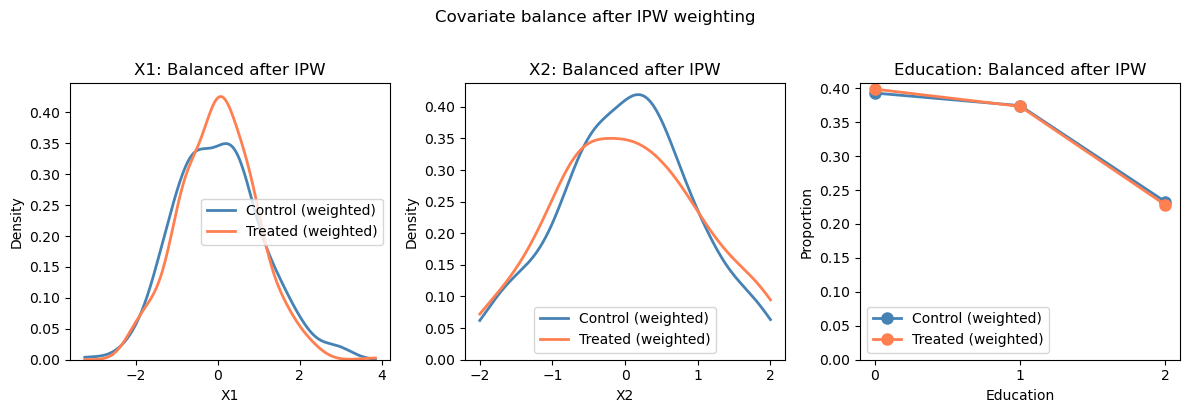

In [108]:
# IPW weights for ATE: 1/e for treated, 1/(1-e) for controls
w_ate = np.where(df['D']==1, 1/ps_clip, 1/(1-ps_clip))
df_temp = df.copy()
df_temp['w'] = w_ate

# Normalize weights within each group for density
w_trt = df_temp[df_temp['D']==1]['w'].values
w_ctrl = df_temp[df_temp['D']==0]['w'].values
w_trt_norm = w_trt / w_trt.sum()
w_ctrl_norm = w_ctrl / w_ctrl.sum()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# X1 (weighted KDE)
x1_trt = df_temp[df_temp['D']==1]['X1'].values
x1_ctrl = df_temp[df_temp['D']==0]['X1'].values
kde_ctrl = stats.gaussian_kde(x1_ctrl, weights=w_ctrl_norm)
kde_trt = stats.gaussian_kde(x1_trt, weights=w_trt_norm)
xx = np.linspace(df['X1'].min(), df['X1'].max(), 200)
axes[0].plot(xx, kde_ctrl(xx), label='Control (weighted)', color='steelblue', linewidth=2)
axes[0].plot(xx, kde_trt(xx), label='Treated (weighted)', color='coral', linewidth=2)
axes[0].set_xlabel('X1')
axes[0].set_ylabel('Density')
axes[0].set_title('X1: Balanced after IPW')
axes[0].legend()
axes[0].set_ylim(bottom=0)

# X2 (weighted KDE)
x2_trt = df_temp[df_temp['D']==1]['X2'].values
x2_ctrl = df_temp[df_temp['D']==0]['X2'].values
kde_ctrl2 = stats.gaussian_kde(x2_ctrl, weights=w_ctrl_norm)
kde_trt2 = stats.gaussian_kde(x2_trt, weights=w_trt_norm)
xx2 = np.linspace(df['X2'].min(), df['X2'].max(), 200)
axes[1].plot(xx2, kde_ctrl2(xx2), label='Control (weighted)', color='steelblue', linewidth=2)
axes[1].plot(xx2, kde_trt2(xx2), label='Treated (weighted)', color='coral', linewidth=2)
axes[1].set_xlabel('X2')
axes[1].set_ylabel('Density')
axes[1].set_title('X2: Balanced after IPW')
axes[1].legend()
axes[1].set_ylim(bottom=0)

# Education (line plot with weighted proportions)
edu_vals = sorted(df['education'].unique())
trt_df = df_temp[df_temp['D']==1]
ctrl_df = df_temp[df_temp['D']==0]
ctrl_pct = [ctrl_df[ctrl_df['education']==e]['w'].sum() / ctrl_df['w'].sum() for e in edu_vals]
trt_pct = [trt_df[trt_df['education']==e]['w'].sum() / trt_df['w'].sum() for e in edu_vals]
x = np.arange(len(edu_vals))
axes[2].plot(x, ctrl_pct, 'o-', label='Control (weighted)', color='steelblue', linewidth=2, markersize=8)
axes[2].plot(x, trt_pct, 'o-', label='Treated (weighted)', color='coral', linewidth=2, markersize=8)
axes[2].set_xlabel('Education')
axes[2].set_ylabel('Proportion')
axes[2].set_title('Education: Balanced after IPW')
axes[2].set_xticks(x)
axes[2].set_xticklabels(edu_vals)
axes[2].legend()
axes[2].set_ylim(bottom=0)

plt.suptitle('Covariate balance after IPW weighting', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Comparison: ATE and ATT Across Methods

In [106]:
# ATT from matching methods (treated only: mean of Y - Y0_hat)
att_exact = np.nanmean((Y1_hat - Y0_hat)[df['D']==1])
# att_nn, att_ps computed in Method 3 and 4 cells
att_naive = ate_naive  # naive uses same formula for both

# Summary table: ATE and ATT with SE and p-value
results = pd.DataFrame({
    'Method': ['Naive', 'Exact matching', 'Nearest-neighbor', 'Propensity score', 'IPW'],
    'ATE': [ate_naive, ate_exact, ate_nn, ate_ps, ate_ipw],
    'ATE_SE': [se_naive, se_exact, se_nn, se_ps, se_ate_ipw],
    'ATE_p': [pval_naive, pval_exact, pval_nn, pval_ps, pval_ate_ipw],
    'ATT': [att_naive, att_exact, att_nn, att_ps, att_ipw],
    'ATT_SE': [se_naive, se_att_exact, se_att_nn, se_att_ps, se_att_ipw],
    'ATT_p': [pval_naive, pval_att_exact, pval_att_nn, pval_att_ps, pval_att_ipw],
    'Bias (ATE)': [ate_naive-TRUE_ATE, ate_exact-TRUE_ATE, ate_nn-TRUE_ATE, ate_ps-TRUE_ATE, ate_ipw-TRUE_ATE]
})
results['True ATE'] = TRUE_ATE
print(results.to_string(index=False))
print()
print("ATE = effect for population; ATT = effect for treated. With selection, ATT ≠ ATE in general.")

          Method       ATE   ATE_SE        ATE_p       ATT   ATT_SE        ATT_p  Bias (ATE)  True ATE
           Naive 14.247527 0.746028 2.072397e-61 14.247527 0.746028 2.072397e-61    4.247527      10.0
  Exact matching 13.538193 0.355510 0.000000e+00 13.728880 0.540114 0.000000e+00    3.538193      10.0
Nearest-neighbor 10.965406 0.526609 0.000000e+00 11.617268 0.696713 0.000000e+00    0.965406      10.0
Propensity score  9.942685 0.560768 0.000000e+00 10.101415 0.697888 0.000000e+00   -0.057315      10.0
             IPW  9.972129 0.507679 0.000000e+00 10.032756 0.620344 0.000000e+00   -0.027871      10.0

ATE = effect for population; ATT = effect for treated. With selection, ATT ≠ ATE in general.


## Summary

For **causal inference** with selection on observables, different matching methods estimate the **ATE**:

1. **Naive** comparison is biased when treatment is not random.
2. **Exact matching** compares within strata of discrete covariates.
3. **Nearest-neighbor** matching imputes counterfactuals from closest units (by covariate or PS distance).
4. **Propensity score** matching reduces dimensionality by matching on $e(X)$.
5. **IPW** reweights all units instead of matching.

All methods require **overlap** and **unconfoundedness**; they do not fix unobserved confounding.